In [313]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


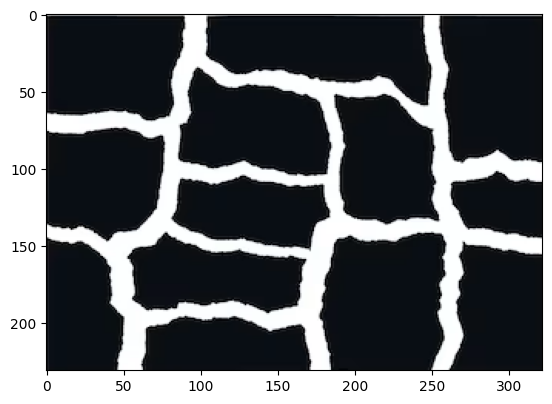

In [314]:
img = cv2.imread(r"Z:\Internship\Tasks\Edge Detection\image\image1.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(img)
plt.show()


In [315]:
thresh=cv2.threshold(gray, 240, 245, cv2.THRESH_BINARY_INV)[1]


In [316]:
# edges = cv2.Canny(thresh, 50, 150)

In [317]:
# plt.imshow(edges,cmap='gray')
# plt.title('Detected contours')
# plt.show() 

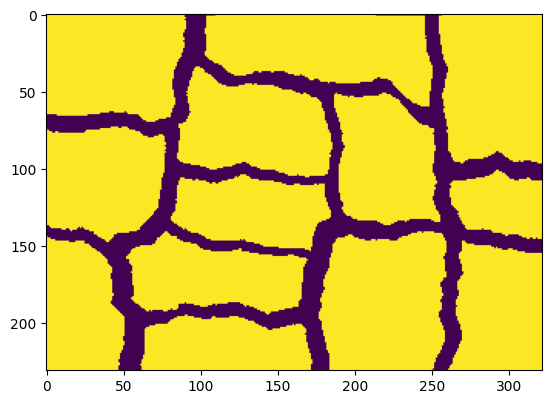

In [318]:
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

img1=img.copy()

mask = np.zeros_like(thresh)
cv2.drawContours(mask, contours, -1, (255,255,255), -1)

plt.imshow(mask)
plt.show()


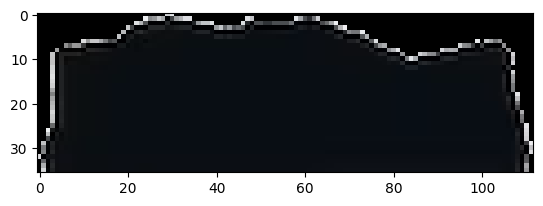

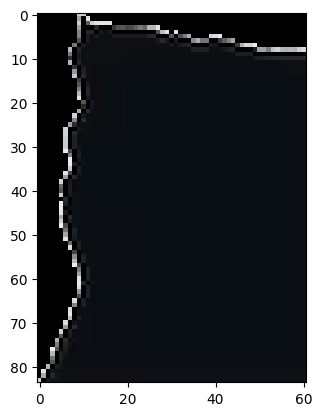

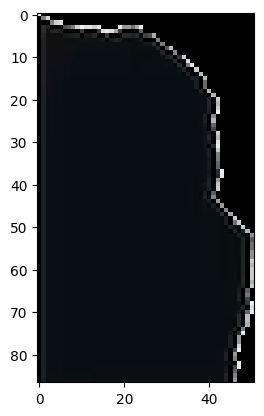

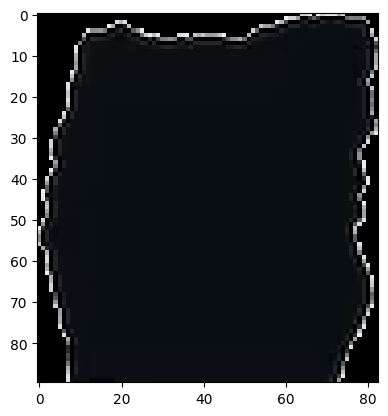

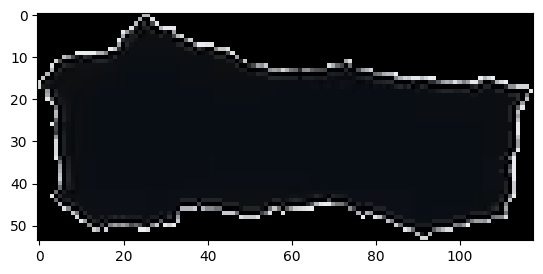

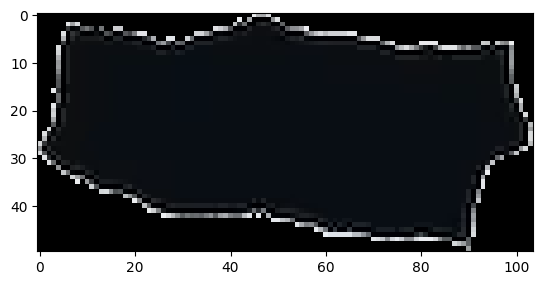

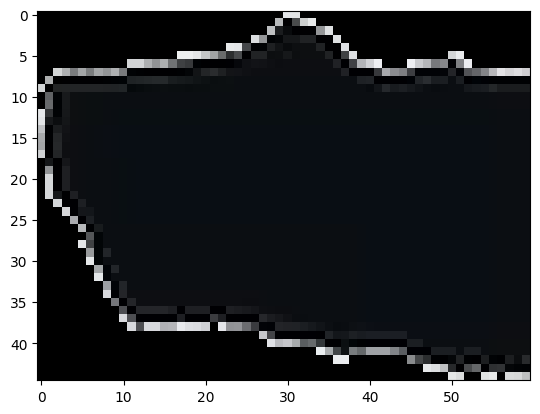

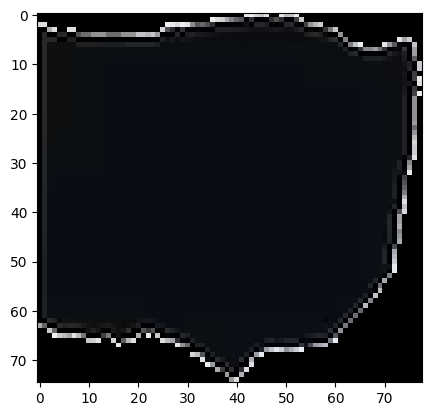

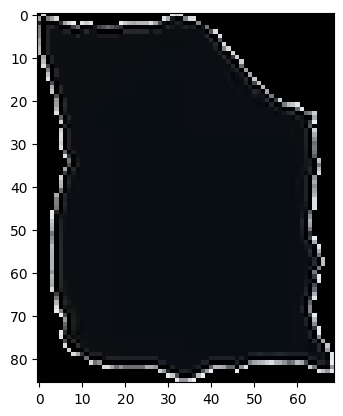

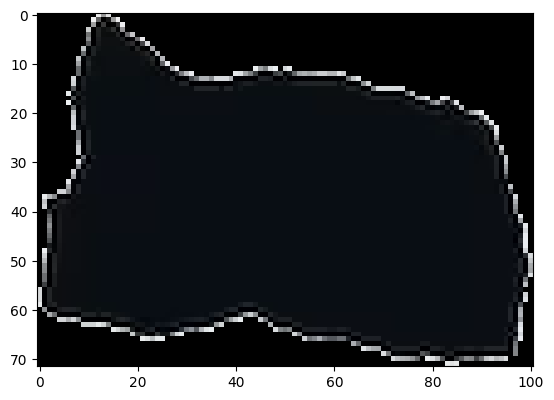

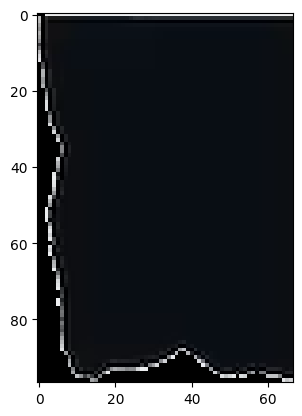

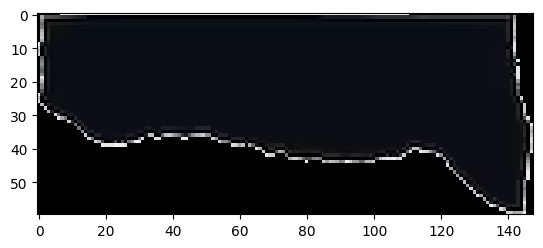

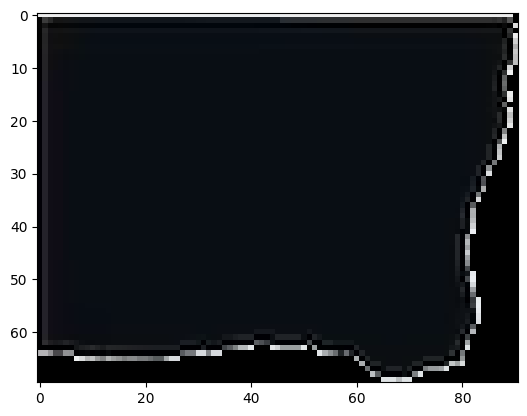

In [319]:
con=[]
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
for i, cnt in enumerate(contours):
    if cv2.contourArea(cnt)<100:
        continue
    mask=np.zeros_like(thresh)
    cv2.drawContours(mask, [cnt],-1,255,thickness=cv2.FILLED)

    isolated_piece=cv2.bitwise_and(img,img,mask=mask)
    x,y,w,h = cv2.boundingRect(cnt)
    cropped_piece=isolated_piece[y:y+h, x:x+w]

    con.append(cropped_piece)

    plt.imshow(cropped_piece)
    plt.show()



In [320]:
# color=cv2.cvtColor(con[0], cv2.COLOR_BGR2GRAY)
# plt.imshow(color,cmap='grey')
# plt.show()
# color=cv2.cvtColor(con[0], cv2.COLOR_BGR2RGB)
# plt.imshow(color,cmap='grey')
# plt.show()
# color=cv2.cvtColor(con[0], cv2.COLOR_BGR2HSV)
# plt.imshow(color,cmap='grey')
# plt.show()
# color=cv2.cvtColor(con[0], cv2.COLOR_RGB2GRAY)
# plt.imshow(color,cmap='grey')
# plt.show()
# color=cv2.cvtColor(con[0], cv2.COLOR_RGB2HSV)
# plt.imshow(color,cmap='grey')
# plt.show()
# color=cv2.cvtColor(con[0], cv2.COLOR_RGB2BGR)
# plt.imshow(color,cmap='grey')
# plt.show()
# color=cv2.cvtColor(con[0], cv2.COLOR_BGR2LUV)
# plt.imshow(color,cmap='grey')
# plt.show()


--- Piece 0 Analysis ---
Identified ROI Sides: Top, Bottom, Left, Right



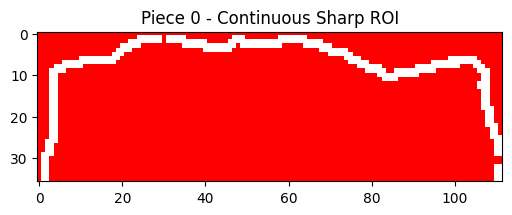

--- Piece 1 Analysis ---
Identified ROI Sides: Top, Bottom, Left, Right



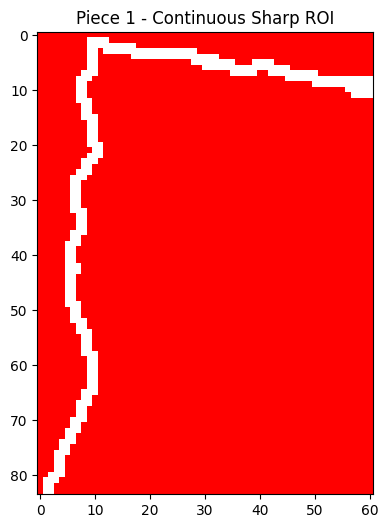

--- Piece 2 Analysis ---
Identified ROI Sides: Top, Bottom, Left, Right



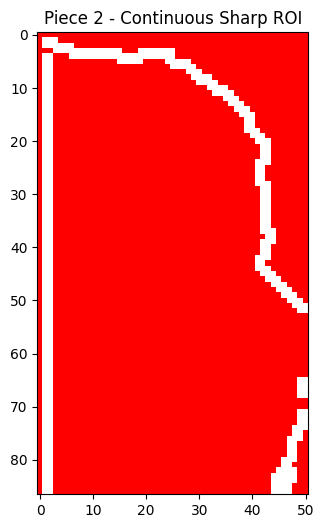

--- Piece 3 Analysis ---
Identified ROI Sides: Top, Bottom, Left, Right



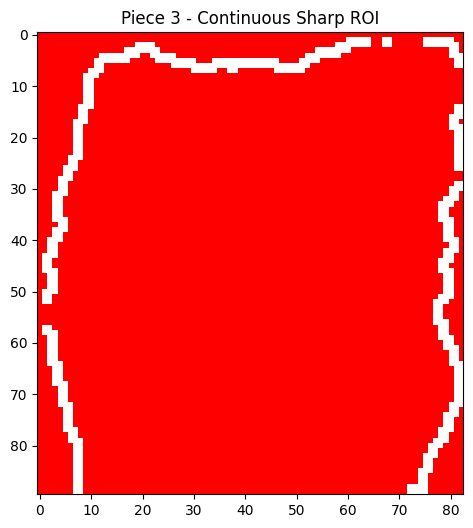

--- Piece 4 Analysis ---
Identified ROI Sides: Top, Bottom, Left, Right



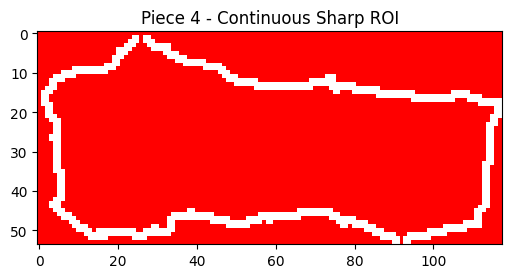

--- Piece 5 Analysis ---
Identified ROI Sides: Top, Bottom, Left, Right



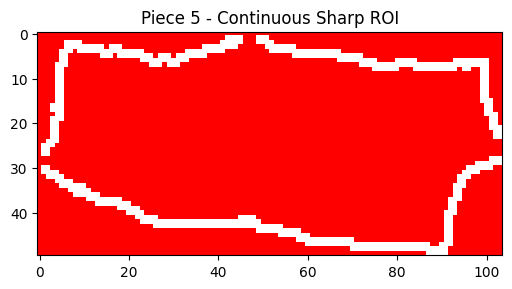

--- Piece 6 Analysis ---
Identified ROI Sides: Top, Bottom, Left, Right



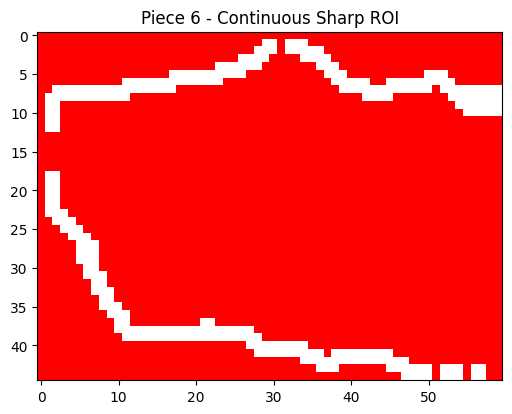

--- Piece 7 Analysis ---
Identified ROI Sides: Top, Bottom, Left, Right



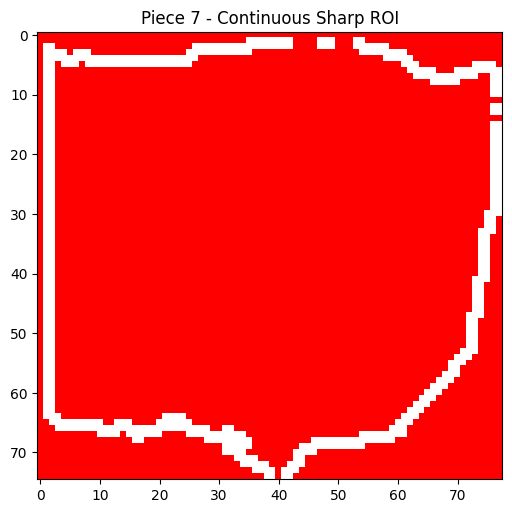

--- Piece 8 Analysis ---
Identified ROI Sides: Top, Bottom, Left, Right



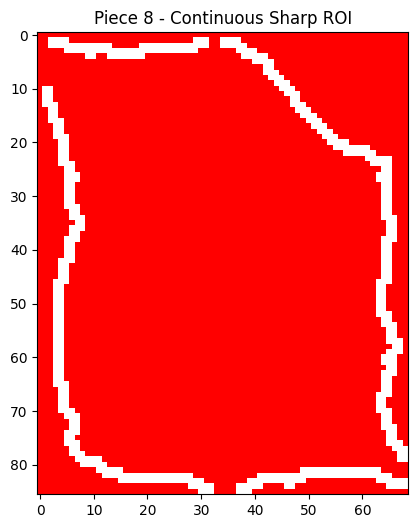

--- Piece 9 Analysis ---
Identified ROI Sides: Top, Bottom, Left, Right



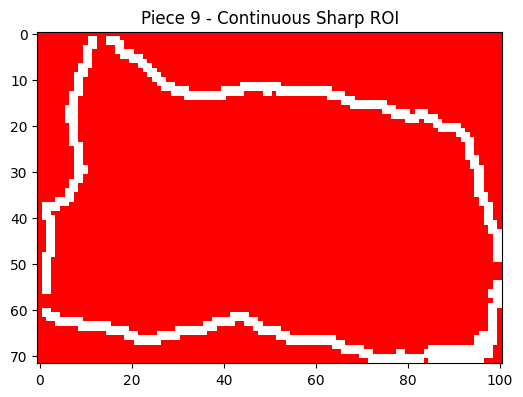

--- Piece 10 Analysis ---
Identified ROI Sides: Top, Bottom, Left, Right



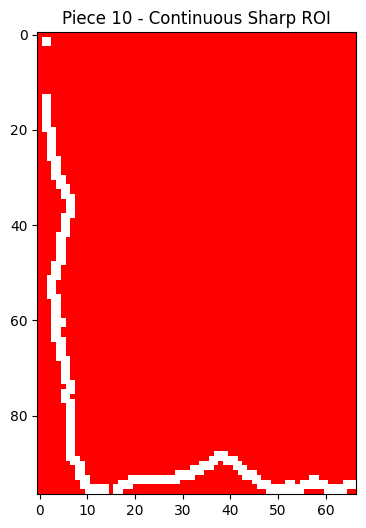

--- Piece 11 Analysis ---
Identified ROI Sides: Top, Bottom, Left, Right



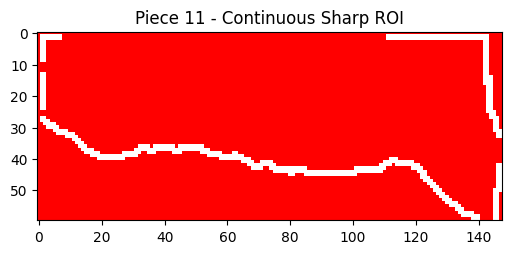

--- Piece 12 Analysis ---
Identified ROI Sides: Top, Bottom, Left, Right



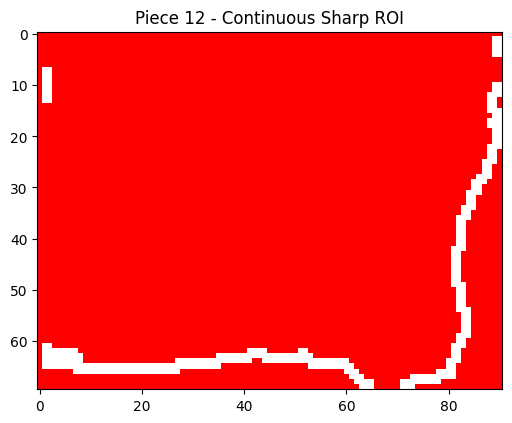

In [ ]:
for i, piece in enumerate(con):
    gray = cv2.cvtColor(piece, cv2.COLOR_BGR2GRAY)
    _, local_mask = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)
    
    local_contours, _ = cv2.findContours(local_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not local_contours: 
        continue
    local_cnt = local_contours[0]
    
    h, w = local_mask.shape
    
    thin_boundary = np.zeros_like(local_mask)
    cv2.drawContours(thin_boundary, [local_cnt], -1, 255, thickness=1)
    
    border_mask = np.zeros_like(local_mask)
    margin = 1 
    cv2.rectangle(border_mask, (margin, margin), (w - (margin + 1), h - (margin + 1)), 255, thickness=-1)
    
    clean_torn_edge_mask = cv2.bitwise_and(thin_boundary, border_mask)
    
    kernel = np.ones((2,2), np.uint8)
    clean_torn_edge_mask = cv2.dilate(clean_torn_edge_mask, kernel, iterations=1)
    
    tear_feature_roi = np.zeros_like(piece)
    tear_feature_roi[:] = [0, 0, 255] # Solid Red
    tear_feature_roi[clean_torn_edge_mask == 255] = [255, 255, 255]
    
    has_top_tear = np.any(clean_torn_edge_mask[0:int(h*0.2), :] == 255)
    has_bottom_tear = np.any(clean_torn_edge_mask[int(h*0.8):h, :] == 255)
    has_left_tear = np.any(clean_torn_edge_mask[:, 0:int(w*0.2)] == 255)
    has_right_tear = np.any(clean_torn_edge_mask[:, int(w*0.8):w] == 255)
    
    sides = []
    if has_top_tear: sides.append("Top")
    if has_bottom_tear: sides.append("Bottom")
    if has_left_tear: sides.append("Left")
    if has_right_tear: sides.append("Right")
    
    print(f"--- Piece {i} Analysis ---")
    print(f"Identified ROI Sides: {', '.join(sides) if sides else 'None'}\n")
    
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(tear_feature_roi, cv2.COLOR_BGR2RGB))
    plt.title(f"Piece {i} - Continuous Sharp ROI")
    plt.show()

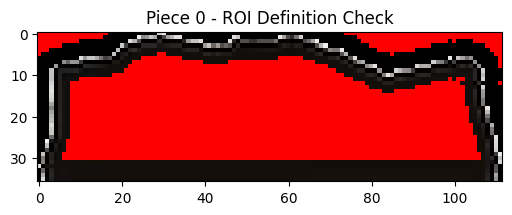

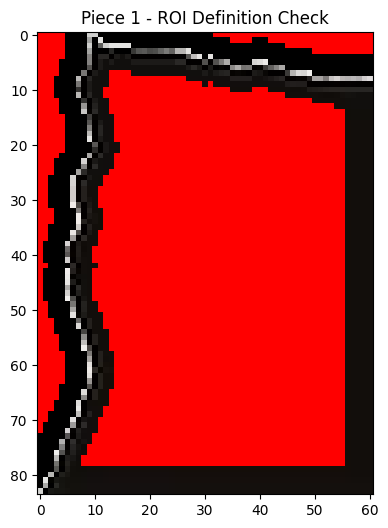

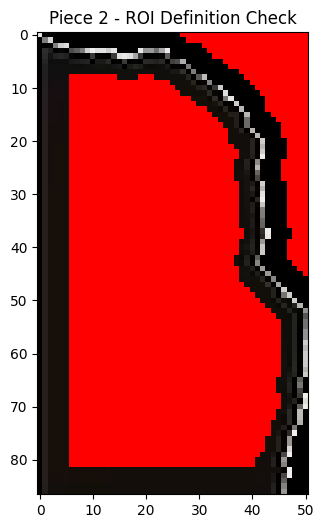

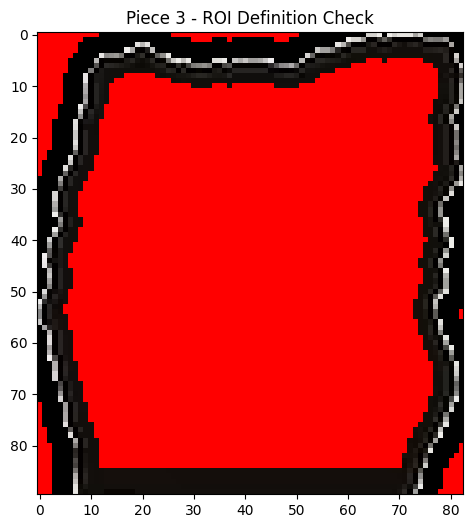

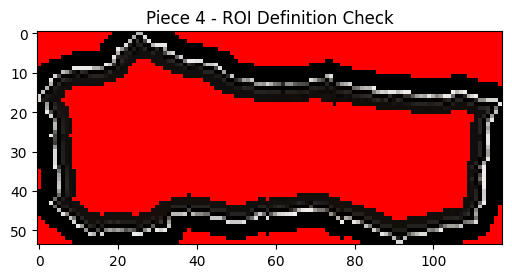

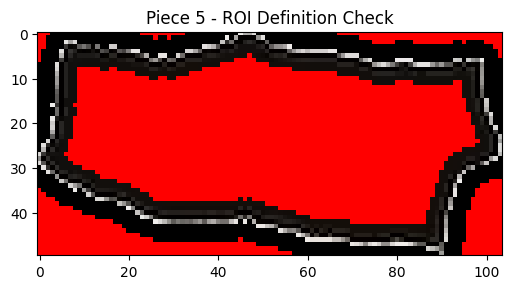

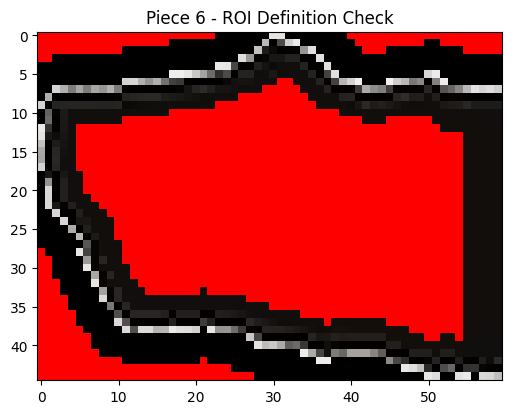

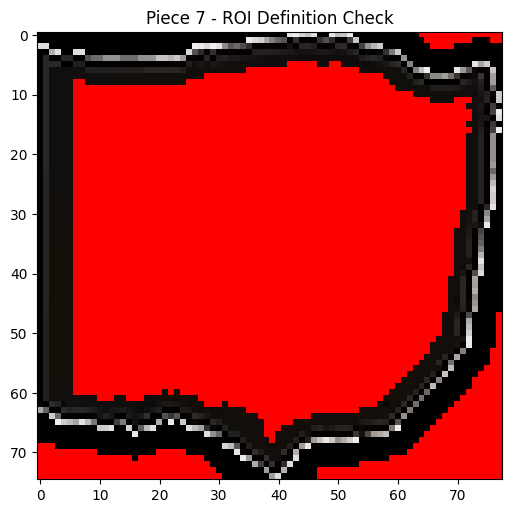

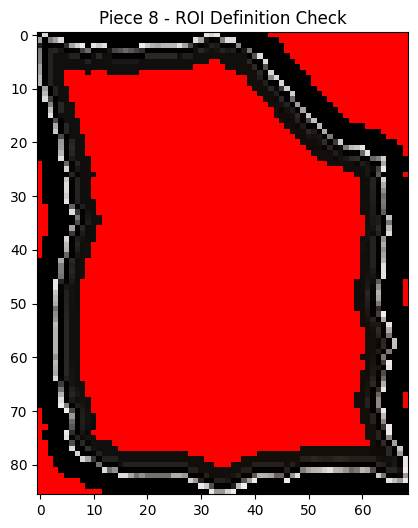

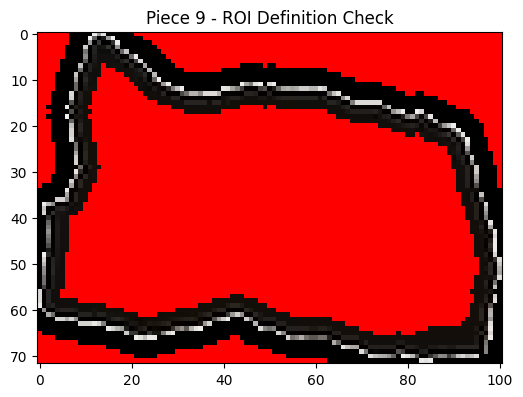

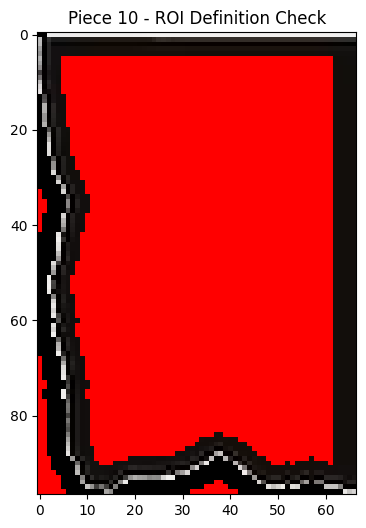

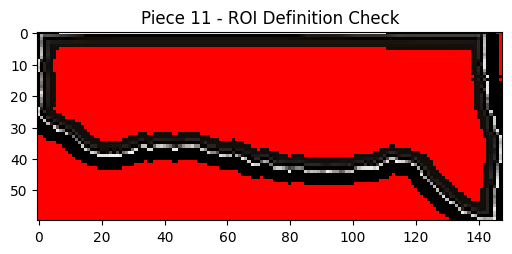

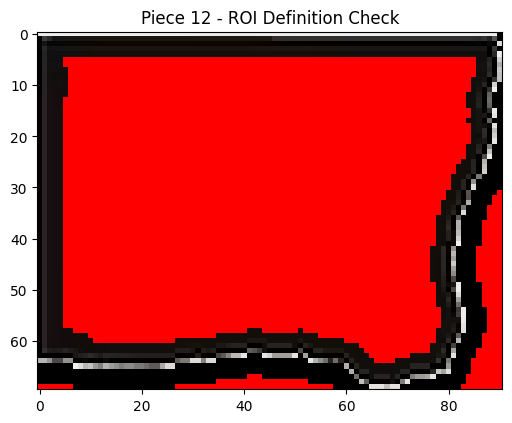

In [322]:
for i, piece in enumerate(con):
    gray = cv2.cvtColor(piece, cv2.COLOR_BGR2GRAY)
    _, local_mask = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)
    
    local_contours, _ = cv2.findContours(local_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not local_contours: 
        continue
    local_cnt = local_contours[0]
    
    edge_mask = np.zeros_like(local_mask)
    cv2.drawContours(edge_mask, [local_cnt], -1, 255, thickness=8) 
    
    colored_background = np.zeros_like(piece)
    colored_background[:] = [0, 0, 255] 
   
    tear_feature_roi = np.where(edge_mask[:, :, None] == 255, piece, colored_background)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(tear_feature_roi, cv2.COLOR_BGR2RGB))
    plt.title(f"Piece {i} - ROI Definition Check")
    plt.show()

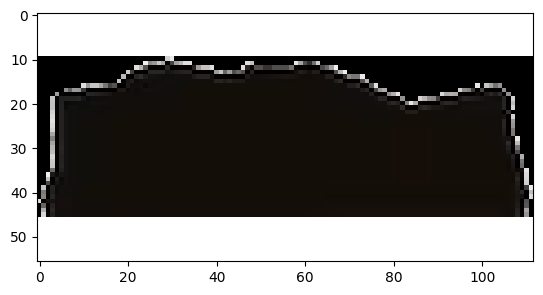

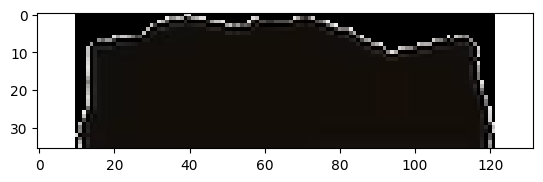

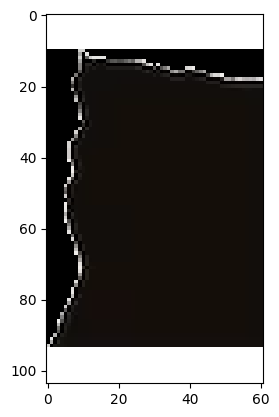

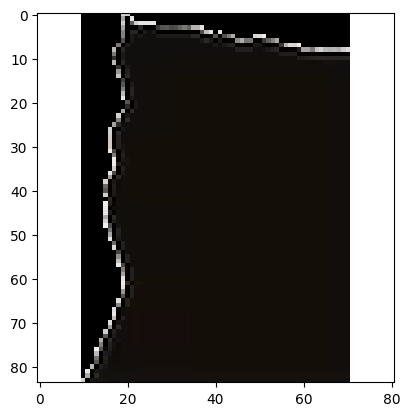

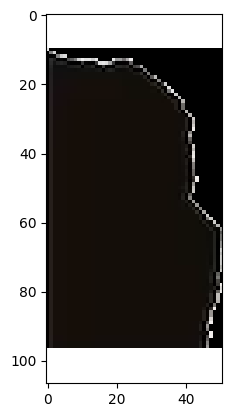

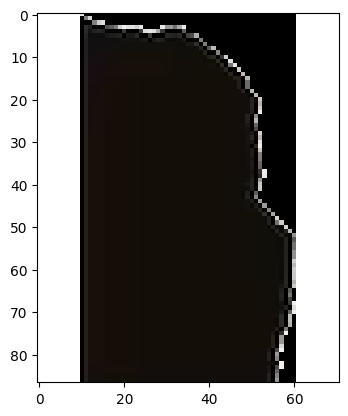

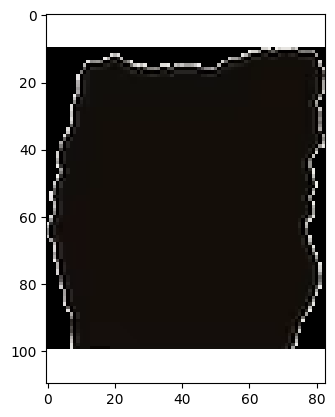

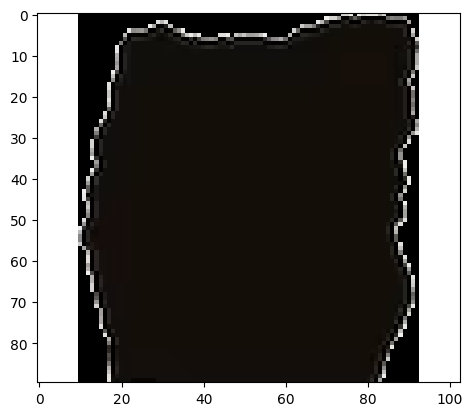

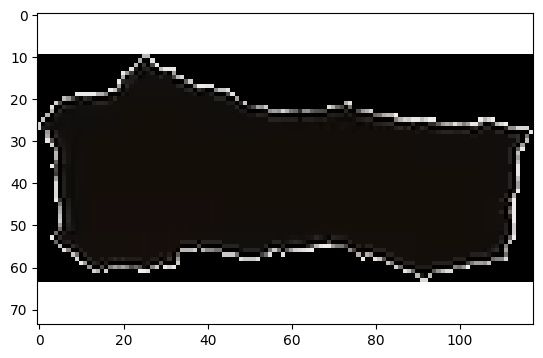

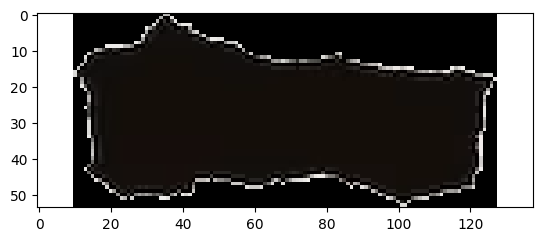

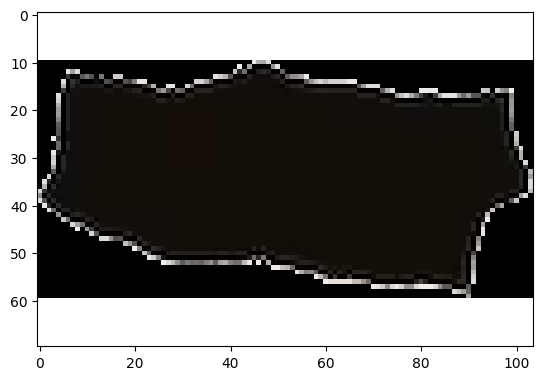

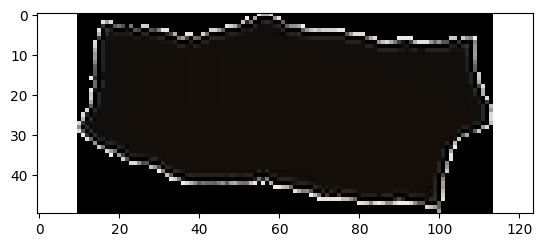

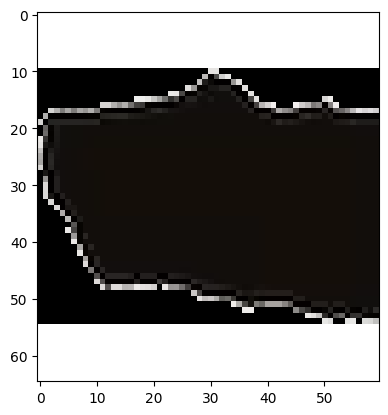

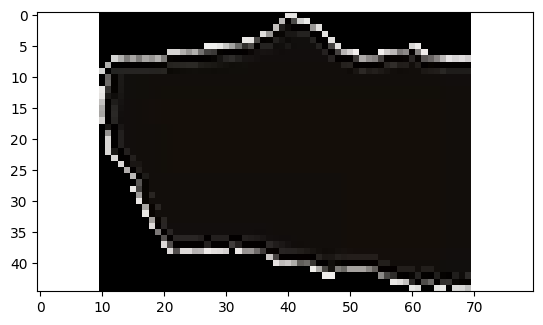

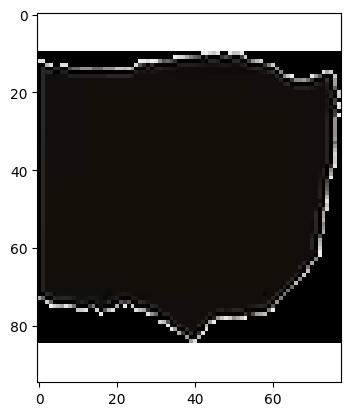

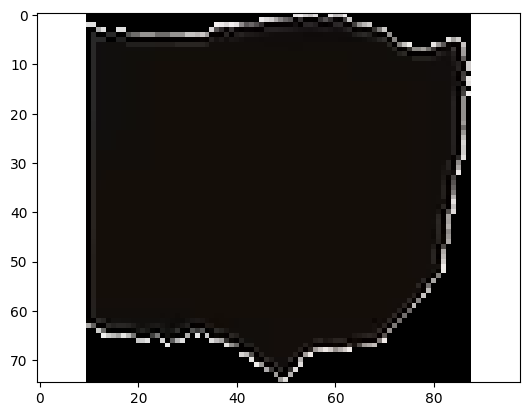

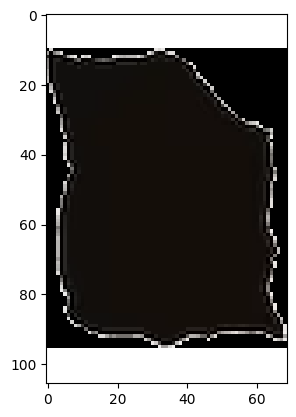

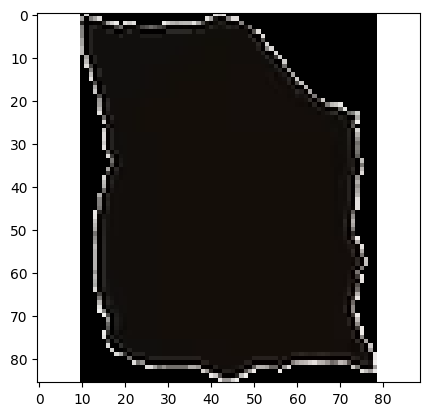

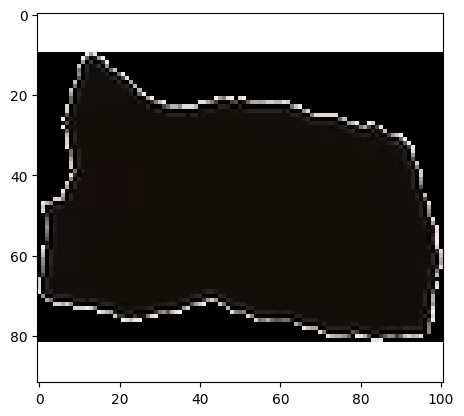

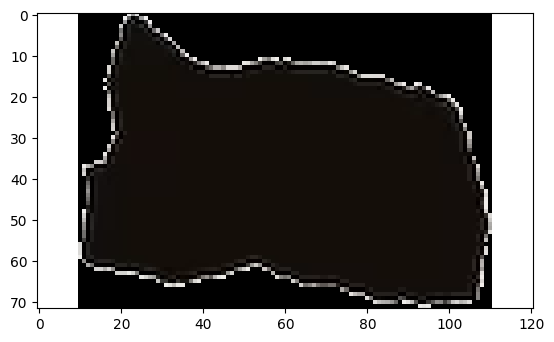

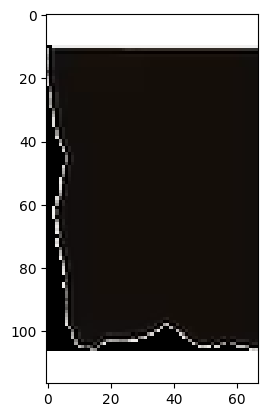

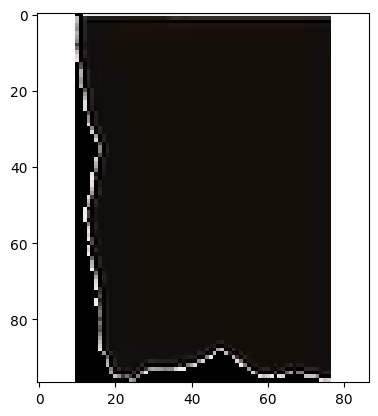

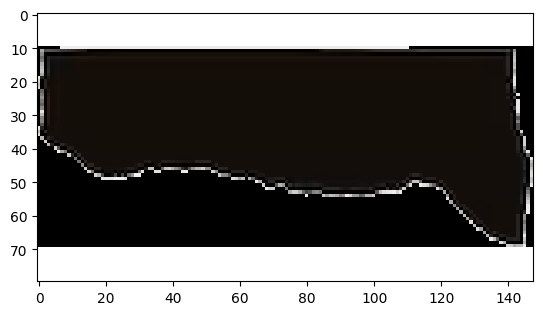

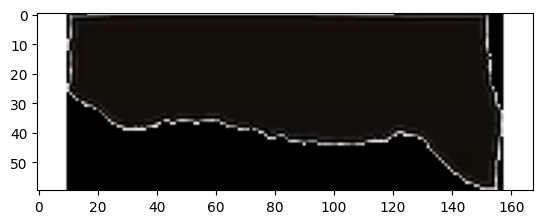

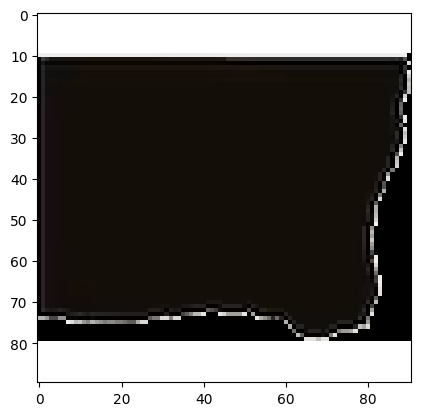

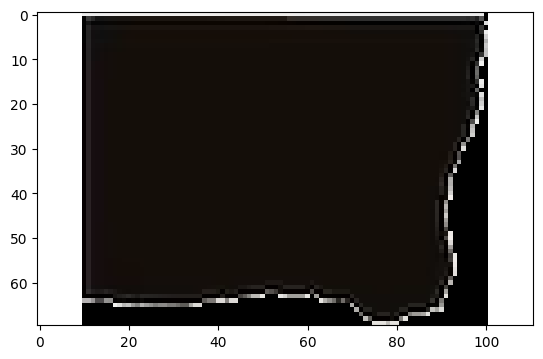

In [323]:
for i in con:
    padded_piece = cv2.copyMakeBorder(i, 10, 10, 0, 0, borderType=cv2.BORDER_CONSTANT, value=[255, 255, 255])
    padded_piece1 = cv2.copyMakeBorder(i, 0, 0, 10, 10, borderType=cv2.BORDER_CONSTANT, value=[255, 255, 255])
    
    plt.imshow(cv2.cvtColor(padded_piece, cv2.COLOR_BGR2RGB))
    plt.show()
    
    plt.imshow(cv2.cvtColor(padded_piece1, cv2.COLOR_BGR2RGB))
    plt.show()

111 25


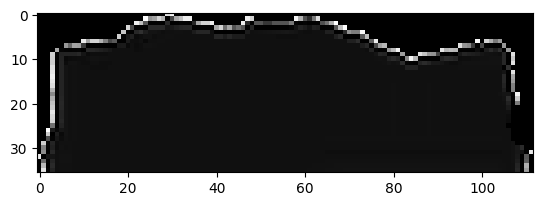

60 7


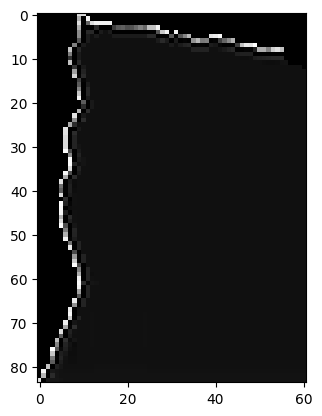

50 50


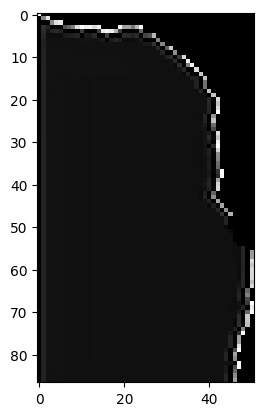

82 3


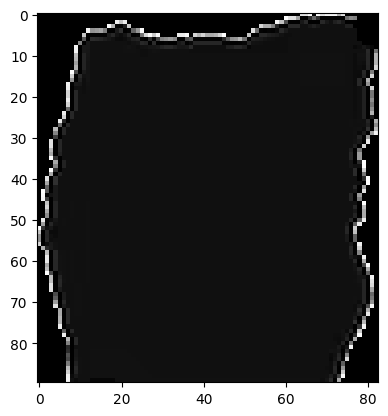

117 17


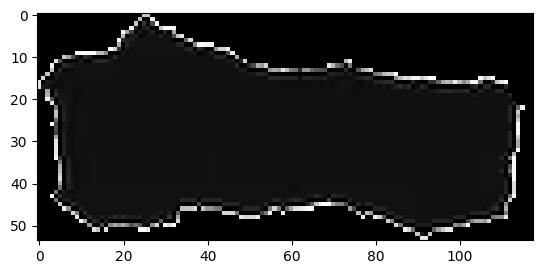

103 20


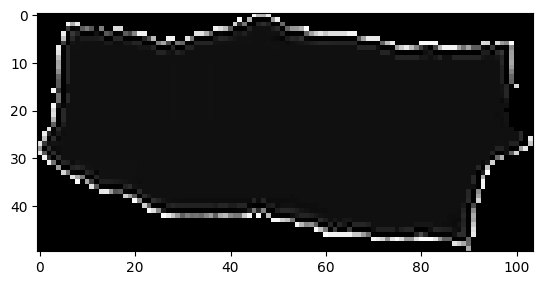

59 6


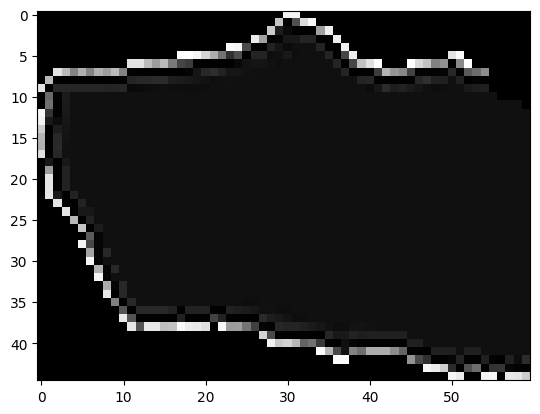

77 5


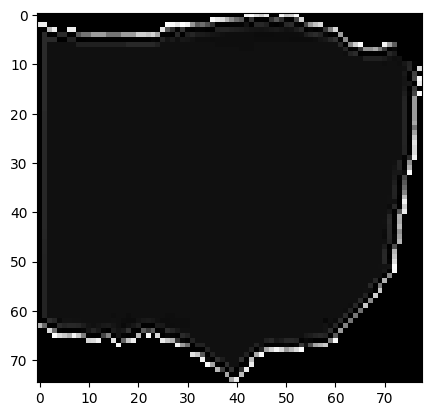

68 76


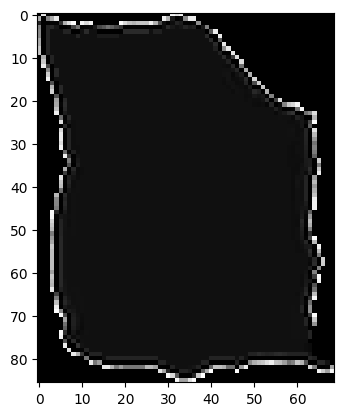

100 43


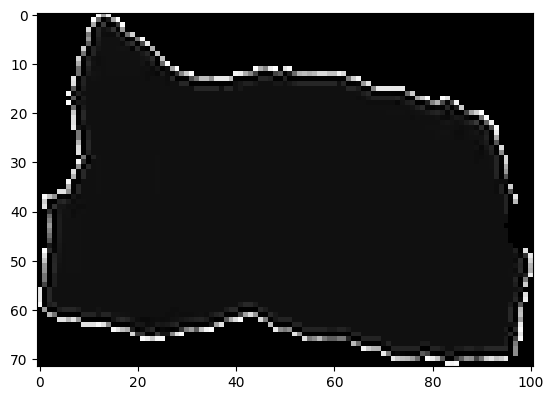

66 1


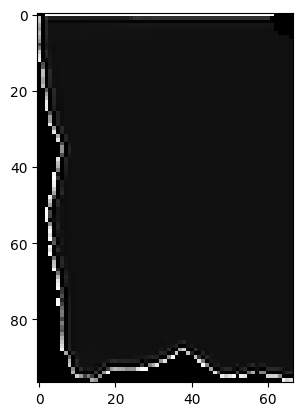

147 30


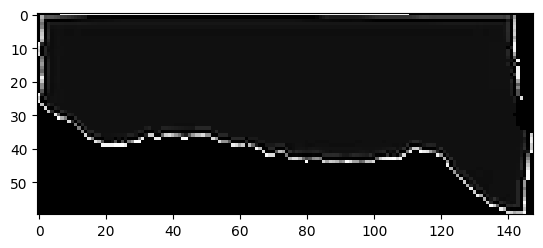

90 1


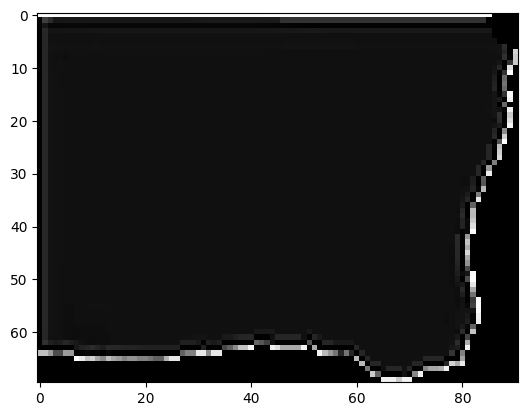

In [324]:
for i in con:
 gray_padded = cv2.cvtColor(i, cv2.COLOR_BGR2GRAY)
 edges = cv2.Canny(gray_padded, 50, 150)
 y,x=np.where(edges==255)
 highest =np.argmin(x)
 highest =np.argmax(x)

 x1=x[highest]
 y1=y[highest]
 print(x1,y1)

 cv2.circle(gray_padded,(x1,y1), 5,(0,0,255),-1)

 plt.imshow(gray_padded, cmap='gray')
 plt.show() 


23 0


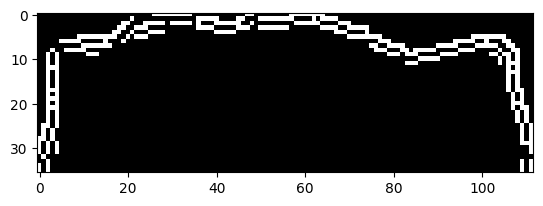

In [325]:
gray_padded = cv2.cvtColor(con[0], cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray_padded, 50, 150)
y,x=np.where(edges==255)
highest =np.argmin(y)
x1=x[highest]
y1=y[highest]
print(x1,y1)

cv2.circle(edges,(x1,y1), 2,(0,0,255),-1)

plt.imshow(edges,cmap='gray')
plt.show()


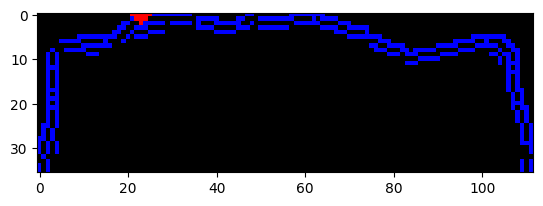

In [326]:
colored_edges = np.zeros((edges.shape[0], edges.shape[1], 3), dtype=np.uint8)

colored_edges[edges == 255] = [255, 0, 0] 

cv2.circle(colored_edges, (x1, y1), 2, (0, 0, 255), -1) 

plt.imshow(cv2.cvtColor(colored_edges, cv2.COLOR_BGR2RGB))
plt.show()

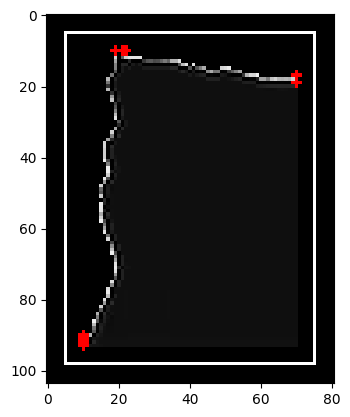

In [327]:
gray_padded = cv2.cvtColor(con[1], cv2.COLOR_BGR2GRAY) if len(con[1].shape) == 3 else con[1].copy()

edges = cv2.Canny(gray_padded, 50, 150)
y, x = np.where(edges == 255)

padding_color = [0, 0, 0] 
output_img = cv2.cvtColor(gray_padded, cv2.COLOR_GRAY2BGR)
output_img = cv2.copyMakeBorder(output_img, 10, 10, 10, 10, borderType=cv2.BORDER_CONSTANT, value=padding_color)

x = x + 10
y = y + 10

bottom = np.max(y)  
right = np.max(x)   
top = np.min(y) 
left = np.min(x)   

y1 = x[y == bottom]
for peak_x in y1:
    cv2.circle(output_img, (peak_x, bottom), 1, (0, 0, 255), -1)

y2 = y[x == right] 
for peak_y in y2:
    cv2.circle(output_img, (right, peak_y), 1, (0, 0, 255), -1) 

y3 = x[y == top] 
for peak_x in y3:
    cv2.circle(output_img, (peak_x, top), 1, (0, 0, 255), -1)

y4 = y[x == left] 
for peak_y in y4:
    cv2.circle(output_img, (left, peak_y), 1, (0, 0, 255), -1)

g1 = 5
b1 = (left - g1, top - g1)
b2 = (right + g1, bottom + g1)
cv2.rectangle(output_img, b1, b2, (255, 255, 255), 1)

plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.show()

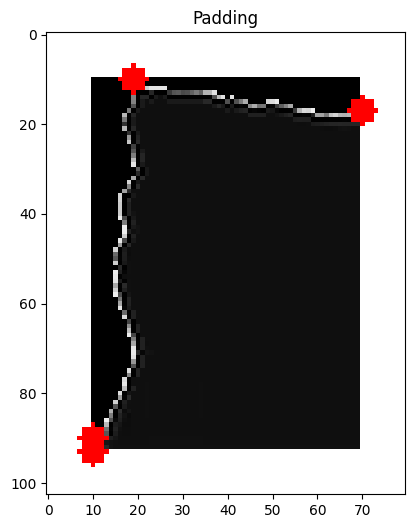

In [328]:
mask = gray_padded < 240 
y, x = np.where(mask & (edges == 255)) 

indices = {"min_x": np.argmin(x),"max_x": np.argmax(x),"min_y": np.argmin(y),"max_y": np.argmax(y)}

pts = [(x[idx], y[idx]) for idx in indices.values()]

xmin, ymin = np.min(pts, axis=0)
xmax, ymax = np.max(pts, axis=0)

cropped_obj = gray_padded[ymin:ymax, xmin:xmax]

padding = 10  
padded_final = cv2.copyMakeBorder(
    cropped_obj, 
    padding, padding, padding, padding, 
    borderType=cv2.BORDER_CONSTANT, 
    value=[255, 255, 255]
)
output_img = cv2.cvtColor(padded_final, cv2.COLOR_GRAY2BGR)

for pt in pts:

    new_x = (pt[0] - xmin) + padding
    new_y = (pt[1] - ymin) + padding
    cv2.circle(output_img, (new_x, new_y), 3, (0, 0, 255), -1)

plt.figure(figsize=(8, 6))
plt.title("Padding")
plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.show()

In [329]:
points=cv2.findNonZero(thresh)
x,y,w,h =cv2.boundingRect(thresh)
print(x,y,w,h)

0 0 322 231


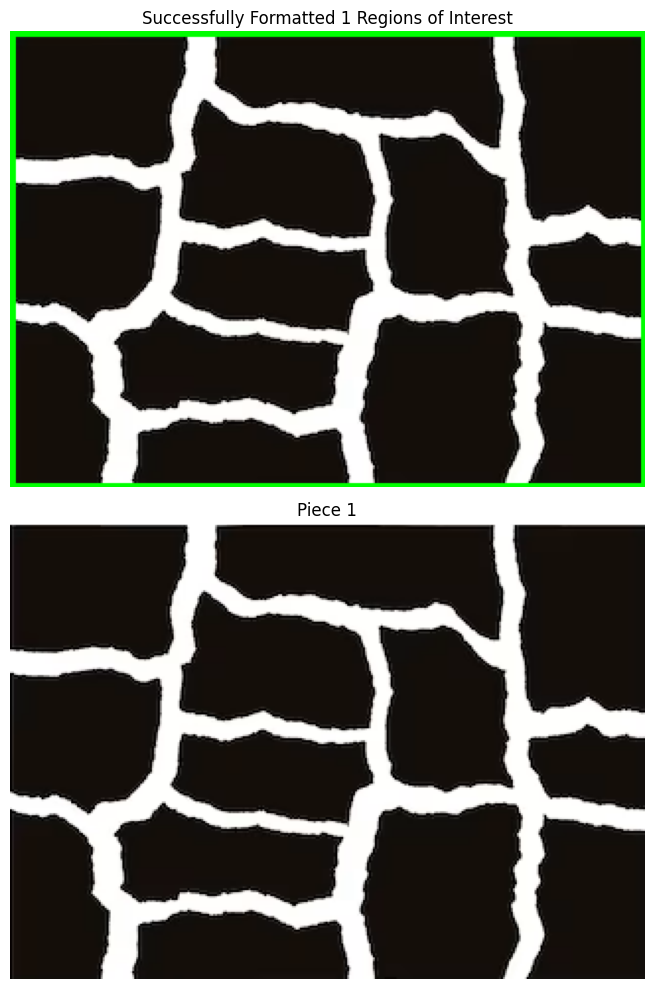

In [330]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the image
path = r'Z:\Internship\Tasks\Edge Detection\image\image1.png'
image_bgr = cv2.imread(path)

if image_bgr is None:
    raise FileNotFoundError(f"Could not load image at path: {path}")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
h_img, w_img, _ = image_rgb.shape
image_copy = image_rgb.copy()

# 2. Preprocessing
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Thresholding to isolate the bright white structures
_, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 3. Find Contours
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

rois = []
min_area = 100  # Lowered to capture smaller segments if necessary
max_area = (h_img * w_img) * 0.95  # Only ignore if it fills the entire image completely

for cnt in contours:
    if isinstance(cnt, np.ndarray) and cnt.shape[0] >= 1:
        area = cv2.contourArea(cnt)
        
        if min_area < area < max_area:
            x, y, w, h = cv2.boundingRect(cnt)
            
            # Crop the target region
            roi = image_rgb[y:y+h, x:x+w]
            rois.append(roi)
            
            # Draw green indicator bounding boxes
            cv2.rectangle(image_copy, (x, y), (x + w, y + h), (0, 255, 0), 3)

# 4. Visualization
num_rois = len(rois)

if num_rois == 0:
    print("No pieces found matching area constraints.")
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(image_rgb)
    axes[0].set_title("Original Image")
    axes[0].axis('off')
    
    axes[1].imshow(thresh, cmap='gray')
    axes[1].set_title("Thresholded Mask")
    axes[1].axis('off')
    plt.show()
else:
    fig = plt.figure(figsize=(16, 10))
    
    # Overview Panel
    ax_main = plt.subplot2grid((2, num_rois), (0, 0), colspan=num_rois)
    ax_main.imshow(image_copy)
    ax_main.set_title(f"Successfully Formatted {num_rois} Regions of Interest")
    ax_main.axis('off')
    
    # Isolated Pieces
    for idx, roi in enumerate(rois):
        ax_roi = plt.subplot2grid((2, num_rois), (1, idx))
        ax_roi.imshow(roi)
        ax_roi.set_title(f"Piece {idx + 1}")
        ax_roi.axis('off')
        
    plt.tight_layout()
    plt.show()